# Step H — CO₂ Shadow Price Analysis

**Model:** The Step D interconnected system (DK extendable, DE/SE/NO fixed).

### Emission factors used (IPCC 2006, Table 2.2)
| Carrier  | ε [tCO₂/MWh_th] | Source |
|----------|-----------------|--------|
| CCGT (gas) | 0.202         | IPCC 2006 |
| Coal       | 0.341         | IPCC 2006 |



## Imports

In [1]:
from pathlib import Path
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

## H0 — Rebuild the Step D network

This block reproduces the full Step D setup exactly.
The key addition here vs. Step D is that **CO₂ emission factors are assigned
to the CCGT and coal carriers** so PyPSA can enforce a GlobalConstraint.

**Emission factors (IPCC 2006, Table 2.2):**
- Natural gas (CCGT): ε = 0.202 tCO₂/MWh_thermal
- Hard coal:          ε = 0.341 tCO₂/MWh_thermal

PyPSA internally computes the electrical-equivalent emission as ε/η,
so we only need to supply the thermal factor and the generator efficiency.


In [2]:
# ── CELL H0a — paths and data loading ───────────────────────
PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "STEP D - electricity_demand.csv").exists():
    PROJECT_DIR = PROJECT_DIR.parent

# --- Denmark data ---
dataframe_dk = pd.read_csv(
    PROJECT_DIR / "DK_2015_merged.csv",
    index_col=0, sep=",", parse_dates=True
)
dataframe_dk.index = pd.to_datetime(dataframe_dk.index, utc=True).tz_localize(None)
dataframe_dk = dataframe_dk.sort_index()

CF_wind  = dataframe_dk["wind_cf_Unnamed: 1"].astype(float)
CF_solar = dataframe_dk["pv_cf_Unnamed: 1"].astype(float)
snapshots = dataframe_dk.index

# --- Multi-country demand ---
demand_all = pd.read_csv(
    PROJECT_DIR / "STEP D - electricity_demand.csv",
    sep=";", index_col=0, parse_dates=True
)
demand_all.index = pd.to_datetime(demand_all.index, utc=True).tz_localize(None)
demand_all = demand_all.sort_index()
demand_2015 = demand_all[demand_all.index.year == 2015].copy()

demand_dk = demand_2015["DNK"].astype(float).reindex(snapshots)
demand_de = demand_2015["DEU"].astype(float).reindex(snapshots)
demand_se = demand_2015["SWE"].astype(float).reindex(snapshots)
demand_no = demand_2015["NOR"].astype(float).reindex(snapshots)

# --- Neighbouring country capacity factors ---
cf_base = PROJECT_DIR / "Other country data" / "Energy charts data"

cf_de_raw = pd.read_csv(cf_base / "Germany" / "Germany_hourly_capacity_factors.csv")
cf_de_raw["timestamp"] = pd.to_datetime(cf_de_raw["timestamp"])
cf_de_raw = cf_de_raw.set_index("timestamp").sort_index()
cf_de_raw.index = cf_de_raw.index.tz_localize(None)
cf_de = cf_de_raw.resample("h").mean()
cf_de["wind_combined"] = cf_de["Wind onshore"]
cf_de["solar"]         = cf_de["Solar AC"]
cf_de["CCGT"]          = cf_de["Fossil gas"]
cf_de = cf_de[["wind_combined", "solar", "CCGT"]].reindex(snapshots)

cf_se = pd.read_csv(cf_base / "Sweden" / "Sweden_hourly_capacity_factors.csv")
cf_se["timestamp"] = pd.to_datetime(cf_se["timestamp"])
cf_se = cf_se.set_index("timestamp").sort_index()
cf_se.index = cf_se.index.tz_localize(None)
cf_se["wind_combined"] = cf_se["Wind onshore"]
cf_se["nuclear"]       = cf_se["Nuclear"]
cf_se["hydro"]         = cf_se["Hydro water reservoir"]
cf_se = cf_se[["wind_combined", "nuclear", "hydro"]].reindex(snapshots).bfill()

cf_no = pd.read_csv(cf_base / "Norway" / "Norway_hourly_capacity_factors.csv")
cf_no["timestamp"] = pd.to_datetime(cf_no["timestamp"])
cf_no = cf_no.set_index("timestamp").sort_index()
cf_no.index = cf_no.index.tz_localize(None)
cf_no["wind_combined"] = cf_no["Wind onshore"]
cf_no["hydro"]         = cf_no["Hydro water reservoir"]
cf_no = cf_no[["wind_combined", "hydro"]].reindex(snapshots)

print("Data loaded successfully.")
print(f"  Snapshots: {len(snapshots)} hours ({snapshots[0]} → {snapshots[-1]})")

Data loaded successfully.
  Snapshots: 8760 hours (2015-01-01 00:00:00 → 2015-12-31 23:00:00)


In [3]:
# ── CELL H0b — cost table (identical to Step D / Step A) ────
data = {
    "capital_cost": [
        1500000/25 + 60000,   # wind:  120,000 $/MW/year
        800000/25  + 14000,   # solar:  46,000 $/MW/year
        700000/25  + 24000,   # CCGT:   52,000 $/MW/year
    ],
    "marginal_cost": [0.0, 0.0, 9.5 * 3.6 / 0.56 + 2.30],  # CCGT: ~63.4 $/MWh
}
costs = pd.DataFrame(data, index=["wind_combined", "solar", "CCGT"])

# Battery parameters (2024 Li-ion, same as Step D)
battery_investment_power  = 100_000   # $/MW
battery_investment_energy = 150_000   # $/MWh
battery_fom               =  12_500   # $/MW/year
battery_lifetime          =      20   # years
battery_max_hours         =       4   # h
battery_efficiency        =    0.90   # round-trip
battery_capital_cost = (
    battery_investment_power  / battery_lifetime
    + battery_fom
    + (battery_investment_energy / battery_lifetime) * battery_max_hours
)

print(f"CCGT capital cost:    {costs.loc['CCGT','capital_cost']:,.0f} $/MW/year")
print(f"Battery capital cost: {battery_capital_cost:,.0f} $/MW/year")

CCGT capital cost:    52,000 $/MW/year
Battery capital cost: 47,500 $/MW/year


In [4]:
# ── CELL H0c — network builder function ─────────────────────
#
# Wrapping the network construction in a function lets us rebuild
# cleanly for the constrained run without carrying stale state.
#
# KEY ADDITION vs Step D:
#   co2_emissions=[0, 0, 0.202, 0, 0, 0.341, 0] on the Carrier add.
#   This tells PyPSA the thermal CO₂ factor per carrier.
#   PyPSA then computes the effective electrical factor as ε/η internally.

# IPCC 2006 CO₂ emission factors [tCO₂/MWh_thermal]
CO2_GAS  = 0.202   # natural gas (Table 2.2, IPCC 2006)
CO2_COAL = 0.341   # hard coal   (Table 2.2, IPCC 2006)

def build_network_h(co2_limit=None):
    """
    Build the Step D interconnected network.
    If co2_limit is given (in tCO₂/year), a GlobalConstraint is added.
    Returns the optimised network.
    """
    n = pypsa.Network()
    n.set_snapshots(snapshots)

    # ── Buses ────────────────────────────────────────────────
    buses = {
        "Denmark": (10.0, 56.0),
        "Germany": (10.5, 51.5),
        "Sweden":  (15.0, 59.5),
        "Norway":  (10.0, 62.0),
    }
    for name, (x, y) in buses.items():
        n.add("Bus", name, x=x, y=y, v_nom=380)

    # ── Carriers — with CO₂ emission factors ─────────────────
    # Order: wind_onshore, solar, CCGT, hydro, nuclear, coal, battery
    n.add(
        "Carrier",
        ["wind_onshore", "solar", "CCGT", "hydro", "nuclear", "coal", "battery"],
        color=["blue", "yellow", "brown", "cyan", "purple", "grey", "violet"],
        co2_emissions=[0, 0, CO2_GAS, 0, 0, CO2_COAL, 0],
    )

    # ── Loads ────────────────────────────────────────────────
    n.add("Load", "load_DK", bus="Denmark", p_set=demand_dk.values)
    n.add("Load", "load_DE", bus="Germany", p_set=demand_de.values)
    n.add("Load", "load_SE", bus="Sweden",  p_set=demand_se.values)
    n.add("Load", "load_NO", bus="Norway",  p_set=demand_no.values)

    # ── Denmark generators (extendable) ──────────────────────
    n.add("Generator", "DK_wind",
          bus="Denmark", carrier="wind_onshore",
          capital_cost=costs.loc["wind_combined", "capital_cost"],
          marginal_cost=costs.loc["wind_combined", "marginal_cost"],
          p_max_pu=CF_wind.values, p_nom_extendable=True)

    n.add("Generator", "DK_solar",
          bus="Denmark", carrier="solar",
          capital_cost=costs.loc["solar", "capital_cost"],
          marginal_cost=costs.loc["solar", "marginal_cost"],
          p_max_pu=CF_solar.values, p_nom_extendable=True)

    n.add("Generator", "DK_CCGT",
          bus="Denmark", carrier="CCGT",
          capital_cost=costs.loc["CCGT", "capital_cost"],
          marginal_cost=costs.loc["CCGT", "marginal_cost"],
          efficiency=0.58, p_nom_extendable=True)

    # ── Germany generators (fixed) ───────────────────────────
    n.add("Generator", "DE_wind",
          bus="Germany", carrier="wind_onshore",
          p_nom=41300, marginal_cost=0,
          p_max_pu=cf_de["wind_combined"].values, p_nom_extendable=False)

    n.add("Generator", "DE_solar",
          bus="Germany", carrier="solar",
          p_nom=37000, marginal_cost=0,
          p_max_pu=cf_de["solar"].values, p_nom_extendable=False)

    n.add("Generator", "DE_CCGT",
          bus="Germany", carrier="CCGT",
          p_nom=28360, marginal_cost=62.0,
          efficiency=0.56, p_nom_extendable=False)

    n.add("Generator", "DE_nuclear",
          bus="Germany", carrier="nuclear",
          p_nom=10800, marginal_cost=11.0, p_nom_extendable=False)

    n.add("Generator", "DE_coal",
          bus="Germany", carrier="coal",
          p_nom=21420, marginal_cost=40.0,
          efficiency=0.40, p_nom_extendable=False)

    # ── Sweden generators (fixed) ────────────────────────────
    n.add("Generator", "SE_hydro",
          bus="Sweden", carrier="hydro",
          p_nom=15920, marginal_cost=5.0,
          p_max_pu=cf_se["hydro"].values, p_nom_extendable=False)

    n.add("Generator", "SE_nuclear",
          bus="Sweden", carrier="nuclear",
          p_nom=8900, marginal_cost=11.0, p_nom_extendable=False)

    n.add("Generator", "SE_wind",
          bus="Sweden", carrier="wind_onshore",
          p_nom=5500, marginal_cost=0,
          p_max_pu=cf_se["wind_combined"].values, p_nom_extendable=False)

    # ── Norway generators (fixed) ────────────────────────────
    n.add("Generator", "NO_hydro",
          bus="Norway", carrier="hydro",
          p_nom=29900, marginal_cost=5.0,
          p_max_pu=cf_no["hydro"].values, p_nom_extendable=False)

    n.add("Generator", "NO_wind",
          bus="Norway", carrier="wind_onshore",
          p_nom=700, marginal_cost=0,
          p_max_pu=cf_no["wind_combined"].values, p_nom_extendable=False)

    # ── Batteries (extendable at all buses) ──────────────────
    for country, bus in [("DK","Denmark"),("DE","Germany"),("SE","Sweden"),("NO","Norway")]:
        n.add("StorageUnit", f"{country}_battery",
              bus=bus, carrier="battery",
              capital_cost=battery_capital_cost,
              marginal_cost=0,
              efficiency_store=battery_efficiency**0.5,
              efficiency_dispatch=battery_efficiency**0.5,
              max_hours=battery_max_hours,
              cyclic_state_of_charge=True,
              p_nom_extendable=True)

    # ── Transmission lines ───────────────────────────────────
    lines = [
        ("line_DK_DE", "Denmark", "Germany", 2380, 350),
        ("line_DK_SE", "Denmark", "Sweden",  2000, 180),
        ("line_DK_NO", "Denmark", "Norway",  1680, 300),
        ("line_SE_NO", "Sweden",  "Norway",  2100, 500),
        ("line_DE_SE", "Germany", "Sweden",   600, 700),
    ]
    for name, bus0, bus1, s_nom, length_km in lines:
        n.add("Line", name,
              bus0=bus0, bus1=bus1,
              s_nom=s_nom, x=0.1, r=0.01, length=length_km,
              p_nom=s_nom)

    # ── Optional CO₂ GlobalConstraint ────────────────────────
    if co2_limit is not None:
        n.add(
            "GlobalConstraint",
            "co2_limit",
            sense="<=",
            carrier_attribute="co2_emissions",
            constant=co2_limit,   # tCO₂/year
        )

    # ── Optimise ─────────────────────────────────────────────
    status, condition = n.optimize(
        solver_name="gurobi",
        solver_options={"output_flag": False}
    )
    if status != "ok":
        raise RuntimeError(f"Optimisation failed: {status} / {condition}")

    return n

print("Network builder function defined.")

Network builder function defined.


## H1 — Compute baseline (unconstrained) emissions E₀

We run the model **without** any CO₂ constraint to find how much the system
emits when only minimising cost. This is our 2015 model baseline $E_0$.

The emitting generators are:
- **DK_CCGT**: η = 0.58, ε = 0.202 tCO₂/MWh_th → 0.348 tCO₂/MWh_el
- **DE_CCGT**: η = 0.56, ε = 0.202 tCO₂/MWh_th → 0.361 tCO₂/MWh_el
- **DE_coal**: η = 0.40, ε = 0.341 tCO₂/MWh_th → 0.853 tCO₂/MWh_el


In [5]:
# ── CELL H1 — unconstrained run ──────────────────────────────
print("Running unconstrained optimisation...")
net_base = build_network_h(co2_limit=None)
print(f"Done. Objective: {net_base.objective/1e9:.3f} B$/year")

# --- Manual emission calculation ---
# (Also available via net_base.global_constraints if a constraint was active,
#  but here we compute it explicitly for transparency.)

emitters = {
    "DK_CCGT": {"eps": 0.202, "eta": 0.58},
    "DE_CCGT": {"eps": 0.202, "eta": 0.56},
    "DE_coal": {"eps": 0.341, "eta": 0.40},
}

print("\n--- Baseline CO₂ emissions by generator ---")
total_E0 = 0.0
for gen, params in emitters.items():
    gen_MWh   = net_base.generators_t.p[gen].sum()          # MWh_el/year
    emissions = gen_MWh * params["eps"] / params["eta"]     # tCO₂/year
    total_E0 += emissions
    print(f"  {gen:<10}: {gen_MWh/1e6:.2f} TWh_el/y  →  {emissions/1e6:.3f} MtCO₂/y")

E0_Mt = total_E0 / 1e6   # MtCO₂/year
print(f"\n  TOTAL E₀ = {E0_Mt:.3f} MtCO₂/year")
print(f"  (= {total_E0:,.0f} tCO₂/year)")

Running unconstrained optimisation...


C:\Users\terry\AppData\Local\Temp\ipykernel_21624\1893141958.py:156: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['Denmark', 'Germany', 'Sweden', 'Norway'], dtype='str', name='name')
DatetimeIndex(['2015-12-31 23:00:00'], dtype='datetime64[us]', name='snapshot', freq=None)
DatetimeIndex(['2015-12-31 23:00:00'], dtype='datetime64[us]', name='snapshot', freq=None)
DatetimeIndex(['2015-12-31 23:00:00'], dtype='datetime64[us]', name='snapshot', freq=None)
DatetimeIndex(['2015-12-31 23:00:00'], dtype='datetime64[us]', name='snapshot', freq=None)
DatetimeIndex(['2015-10-25 01:00:00', '2015-12-31 23:00:00'], dtype='datetime64[us]', name='snapshot', freq=None)
DatetimeIndex(['2015-08-06 22:00:00', '2015-08-06 23:00:00',
               '2015-08-07 00:

Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2773895


...

Reading time = 3.55 seconds


INFO:gurobipy:Reading time = 3.55 seconds


obj: 613207 rows, 262807 columns, 1116871 nonzeros


INFO:gurobipy:obj: 613207 rows, 262807 columns, 1116871 nonzeros
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 262807 primals, 613207 duals
Objective: 2.34e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance were not assigned to the network.


Done. Objective: 23.389 B$/year

--- Baseline CO₂ emissions by generator ---
  DK_CCGT   : 1.46 TWh_el/y  →  0.508 MtCO₂/y
  DE_CCGT   : 113.50 TWh_el/y  →  40.940 MtCO₂/y
  DE_coal   : 187.15 TWh_el/y  →  159.548 MtCO₂/y

  TOTAL E₀ = 200.995 MtCO₂/year
  (= 200,994,824 tCO₂/year)


## H2 — Choose the decarbonisation target

We target a **50% reduction from the model baseline E₀**, which is broadly
consistent with the EU's Fit for 55 target (55% reduction by 2030 vs. 1990).

Note: our model represents a single optimised year (2015) and does not
capture investment pathways. The cap is a static constraint, not a trajectory.


In [6]:
# ── CELL H2 — set the CO₂ target ────────────────────────────
REDUCTION = 0.30   # 50% reduction from baseline

co2_target_t = total_E0 * (1 - REDUCTION)   # tCO₂/year  ← passed to PyPSA
co2_target_Mt = co2_target_t / 1e6

print(f"Baseline emissions E₀:  {E0_Mt:.3f} MtCO₂/year")
print(f"Reduction target:       {REDUCTION*100:.0f}%")
print(f"CO₂ cap:                {co2_target_Mt:.3f} MtCO₂/year")
print(f"                        ({co2_target_t:,.0f} tCO₂/year — value passed to PyPSA)")

Baseline emissions E₀:  200.995 MtCO₂/year
Reduction target:       30%
CO₂ cap:                140.696 MtCO₂/year
                        (140,696,377 tCO₂/year — value passed to PyPSA)


## H3 — Run the constrained optimisation

We now re-run with the CO₂ GlobalConstraint active.
The **shadow price** (dual variable / Lagrange multiplier) of this constraint
is the marginal cost of reducing emissions by 1 tCO₂ at the optimum —
i.e., the system-wide CO₂ price needed to achieve this decarbonisation level.


In [7]:
# ── CELL H3 — constrained run ────────────────────────────────
print(f"Running constrained optimisation (cap = {co2_target_Mt:.3f} MtCO₂/year)...")
net_co2 = build_network_h(co2_limit=co2_target_t)
print(f"Done. Objective: {net_co2.objective/1e9:.3f} B$/year")

# --- Extract shadow price ---
# PyPSA stores dual variables of GlobalConstraints in net.global_constraints["mu"]
# The sign convention: mu >= 0 means the constraint is binding and costly.
shadow_price = abs(net_co2.global_constraints.loc["co2_limit", "mu"])
print(f"\nCO₂ shadow price (μ): {shadow_price:.2f} $/tCO₂")

# --- Verify actual emissions under the constrained solution ---
print("\n--- Constrained emissions by generator ---")
total_E_constrained = 0.0
for gen, params in emitters.items():
    gen_MWh   = net_co2.generators_t.p[gen].sum()
    emissions = gen_MWh * params["eps"] / params["eta"]
    total_E_constrained += emissions
    print(f"  {gen:<10}: {gen_MWh/1e6:.2f} TWh_el/y  →  {emissions/1e6:.3f} MtCO₂/y")

print(f"\n  TOTAL constrained = {total_E_constrained/1e6:.3f} MtCO₂/year")
print(f"  Target cap        = {co2_target_Mt:.3f} MtCO₂/year")
print(f"  Constraint binding: {abs(total_E_constrained - co2_target_t) < 1e3}")

Running constrained optimisation (cap = 140.696 MtCO₂/year)...


C:\Users\terry\AppData\Local\Temp\ipykernel_21624\1893141958.py:156: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['Denmark', 'Germany', 'Sweden', 'Norway'], dtype='str', name='name')
DatetimeIndex(['2015-12-31 23:00:00'], dtype='datetime64[us]', name='snapshot', freq=None)
DatetimeIndex(['2015-12-31 23:00:00'], dtype='datetime64[us]', name='snapshot', freq=None)
DatetimeIndex(['2015-12-31 23:00:00'], dtype='datetime64[us]', name='snapshot', freq=None)
DatetimeIndex(['2015-12-31 23:00:00'], dtype='datetime64[us]', name='snapshot', freq=None)
DatetimeIndex(['2015-10-25 01:00:00', '2015-12-31 23:00:00'], dtype='datetime64[us]', name='snapshot', freq=None)
DatetimeIndex(['2015-08-06 22:00:00', '2015-08-06 23:00:00',
               '2015-08-07 00:

Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2773895


...

Reading time = 0.90 seconds


INFO:gurobipy:Reading time = 0.90 seconds


obj: 613208 rows, 262807 columns, 1143151 nonzeros


INFO:gurobipy:obj: 613208 rows, 262807 columns, 1143151 nonzeros
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 262807 primals, 613208 duals
Objective: 2.60e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance were not assigned to the network.


Done. Objective: 25.962 B$/year

CO₂ shadow price (μ): 44.73 $/tCO₂

--- Constrained emissions by generator ---
  DK_CCGT   : 0.97 TWh_el/y  →  0.337 MtCO₂/y
  DE_CCGT   : 221.06 TWh_el/y  →  79.741 MtCO₂/y
  DE_coal   : 71.11 TWh_el/y  →  60.619 MtCO₂/y

  TOTAL constrained = 140.696 MtCO₂/year
  Target cap        = 140.696 MtCO₂/year
  Constraint binding: True


## H4 — Compare optimal capacities: baseline vs constrained

How does the CO₂ cap change what gets built in Denmark?


In [8]:
# ── CELL H4 — capacity comparison ───────────────────────────
dk_gens   = ["DK_wind", "DK_solar", "DK_CCGT"]
dk_batt   = ["DK_battery"]

print("=== Denmark optimal capacities [GW] ===")
print(f"{'Generator':<12} {'Baseline':>10} {'Constrained':>13} {'Change':>10}")
print("-" * 50)
for gen in dk_gens + dk_batt:
    if gen in net_base.generators.index:
        base_val = net_base.generators.loc[gen, "p_nom_opt"]
        co2_val  = net_co2.generators.loc[gen, "p_nom_opt"]
    else:
        base_val = net_base.storage_units.loc[gen, "p_nom_opt"]
        co2_val  = net_co2.storage_units.loc[gen, "p_nom_opt"]
    pct = (co2_val - base_val) / base_val * 100 if base_val > 0 else float("nan")
    print(f"  {gen:<12} {base_val/1e3:>8.2f} GW   {co2_val/1e3:>8.2f} GW   {pct:>+8.1f}%")

print(f"\nSystem cost increase: "
      f"{(net_co2.objective - net_base.objective)/1e6:+.1f} M$/year "
      f"({(net_co2.objective/net_base.objective - 1)*100:+.1f}%)")

=== Denmark optimal capacities [GW] ===
Generator      Baseline   Constrained     Change
--------------------------------------------------
  DK_wind          4.44 GW      10.32 GW     +132.3%
  DK_solar         0.00 GW       0.22 GW       +nan%
  DK_CCGT          8.80 GW       8.57 GW       -2.7%
  DK_battery       0.01 GW       0.00 GW     -100.0%

System cost increase: +2572.9 M$/year (+11.0%)


## H5 — Compare with real-world CO₂ prices

Reference prices (2015 values unless stated):
| Scheme | Price [$/tCO₂] | Notes |
|--------|---------------|-------|
| EU ETS (2015) | ~7 | Very low due to surplus allowances (source: Ember) |
| EU ETS (2024) | ~60–70 | Post-reform recovery |
| Denmark CO₂ tax (2015) | ~30 | On top of ETS (source: World Bank CPD) |
| Denmark CO₂ tax (2030 target) | ~160 | Danish Climate Act 2020 |
| Sweden carbon tax (2015) | ~120 | One of the world's highest (source: World Bank CPD) |

Source: World Bank Carbon Pricing Dashboard; Ember European Carbon Price Tracker


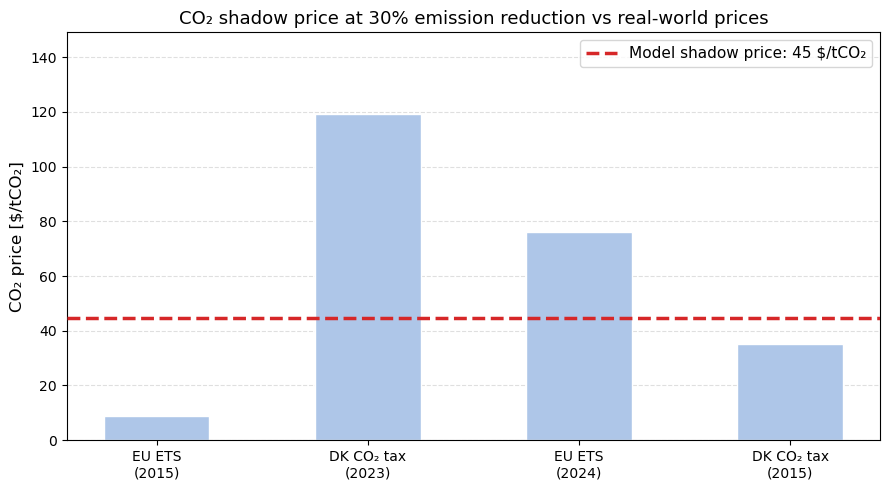

Figure saved.


In [9]:
# ── CELL H5 — shadow price vs real-world comparison plot ─────
fig, ax = plt.subplots(figsize=(9, 5))

# Real-world reference prices [$/tCO₂]
references = {
    "EU ETS\n(2015)": 8.94,
    "DK CO₂ tax\n(2023)": 119.29,
    "EU ETS\n(2024)": 76.26,
    "DK CO₂ tax\n(2015)": 35.20,  

}

labels = list(references.keys())
prices = list(references.values())
colors = ["#aec6e8"] * len(labels)

bars = ax.bar(labels, prices, color=colors, edgecolor="white", width=0.5, zorder=2)

# Model shadow price as horizontal line
ax.axhline(shadow_price, color="#d62728", linewidth=2.5, linestyle="--", zorder=3,
           label=f"Model shadow price: {shadow_price:.0f} $/tCO₂")

ax.set_ylabel("CO₂ price [$/tCO₂]", fontsize=12)
ax.set_title(
    f"CO₂ shadow price at {REDUCTION*100:.0f}% emission reduction vs real-world prices",
    fontsize=13
)
ax.legend(fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=1)
ax.set_ylim(0, max(max(prices), shadow_price) * 1.25)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f"))

plt.tight_layout()
plt.savefig("step_H_shadow_price_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

## H6 — Summary and discussion


In [10]:
# ── CELL H6 — print summary table ───────────────────────────
shadow_price = abs(net_co2.global_constraints.loc["co2_limit", "mu"])
print("="*55)
print("  STEP H — Summary")
print("="*55)
print(f"  Baseline emissions E₀:       {E0_Mt:.3f} MtCO₂/year")
print(f"  CO₂ cap ({REDUCTION*100:.0f}% reduction):     {co2_target_Mt:.3f} MtCO₂/year")
print(f"  Actual constrained emissions: {total_E_constrained/1e6:.3f} MtCO₂/year")
print(f"  CO₂ shadow price (μ):         {shadow_price:.1f} $/tCO₂")
print(f"  System cost increase:         "
      f"{(net_co2.objective - net_base.objective)/1e6:.1f} M$/year")
print("="*55)
print()
print("Real-world reference prices:")
for name, price in references.items():
    marker = "<-- model" if abs(price - shadow_price) == min(
        abs(p - shadow_price) for p in prices) else ""
    print(f"  {name.replace(chr(10),' '):<30} {price:>5} $/tCO₂  {marker}")
print()


  STEP H — Summary
  Baseline emissions E₀:       200.995 MtCO₂/year
  CO₂ cap (30% reduction):     140.696 MtCO₂/year
  Actual constrained emissions: 140.696 MtCO₂/year
  CO₂ shadow price (μ):         44.7 $/tCO₂
  System cost increase:         2572.9 M$/year

Real-world reference prices:
  EU ETS (2015)                   8.94 $/tCO₂  
  DK CO₂ tax (2023)              119.29 $/tCO₂  
  EU ETS (2024)                  76.26 $/tCO₂  
  DK CO₂ tax (2015)               35.2 $/tCO₂  <-- model



STEP I 

In [11]:
# --- CELL I-1: Calculate Hourly Heat Demand ---
# Reference temperature for heating threshold
T_REF = 17.0 

# Load weather data (ensure the file is in your directory)
weather_2015 = pd.read_csv("weather_data_2015_filtered.csv", index_col=0, parse_dates=True)
weather_2015.index = snapshots

# Calculate HDH: max(0, T_ref - T_ambient)
hdh_data = (T_REF - weather_2015).clip(lower=0)

# Annual demands from HRE4 (2015 residential) in MWh
annual_heat_demand = {
    "DE": {"space": 675.0e6, "water": 143.0e6},
    "DK": {"space":  33.6e6, "water":   7.7e6},
    "SE": {"space":  33.6e6, "water":   7.7e6},
    "NO": {"space":  17.8e6, "water":   4.1e6},
}

heat_profiles = pd.DataFrame(index=snapshots)
for code in ["DE", "DK", "SE", "NO"]:
    f1 = annual_heat_demand[code]["space"] / hdh_data[f"Temp_{code}"].sum() # Scaling factor
    water_base = annual_heat_demand[code]["water"] / 8760
    heat_profiles[code] = (f1 * hdh_data[f"Temp_{code}"]) + water_base

print("Heat demand profiles calculated.")

Heat demand profiles calculated.


In [12]:
# --- CELL I-2: Technology Assumptions ---
WACC = 0.07
def get_annuity(lifetime, rate):
    return (rate * (1 + rate)**lifetime) / ((1 + rate)**lifetime - 1)

# Large-scale Air-Source Heat Pump
hp_inv = 730000 # $/MW_elec
hp_fom = 12500  # $/MW_elec/year
hp_annuity = hp_inv * get_annuity(25, WACC) + hp_fom

# CHP Efficiencies (Gas -> Electricity + Heat)
# Standard values for modern CCGT-CHP
CHP_ETA_E = 0.45 
CHP_ETA_Q = 0.45 
# Total efficiency 0.90

In [14]:
# --- CELL I-3: FINAL Sector Coupling (Ultra-Safe Version) ---

# 0. CONFIGURAZIONE MANUALE (Valori fissi per evitare NameError)
countries_map = {"DK": "Denmark", "DE": "Germany", "SE": "Sweden", "NO": "Norway"}
h2_eta_el, h2_eta_fc, h2_pipe_eta = 0.70, 0.58, 0.97
h2_el_capex, h2_fc_capex = 36000.0, 52000.0
h2_connections = [("DK", "DE", 3600), ("DK", "SE", 1500), ("DK", "NO", 2000), ("SE", "NO", 2000), ("DE", "SE", 1000)]

# 1. Ricalcolo CO2 e Inizializzazione Network
net_temp = build_network_h(co2_limit=1e15)
load_map = {"Denmark": "load_DK", "Germany": "load_DE", "Sweden": "load_SE", "Norway": "load_NO"}
tot_elec_demand = sum(net_temp.loads_t.p[l_id].sum() for l_id in load_map.values())
tot_heat_demand = sum(heat_profiles[code].sum() for code in countries_map.keys())
demand_ratio = (tot_elec_demand + (tot_heat_demand/3.0)) / tot_elec_demand
new_co2_limit = (140.696 * 1e6) * demand_ratio

net_i = build_network_h(co2_limit=new_co2_limit)
net_i.carriers.loc["gas", "co2_emissions"] = 0.202
net_i.carriers.loc["CCGT", "co2_emissions"] = 0.202
net_i.carriers.loc["coal", "co2_emissions"] = 0.341

# 2. OVERRIDE DINAMICO (Cerca i componenti Danimarca senza sbagliare nome)
for gen in net_i.generators.index:
    if "DK" in gen or "Denmark" in gen:
        if "wind" in gen:
            net_i.generators.loc[gen, "p_nom"] = 5.94 * 1e3 # Step D Data
        elif "solar" in gen:
            net_i.generators.loc[gen, "p_nom"] = 0.0        # Step D Data

# 3. SBLOCCO BROWNFIELD 3X
for gen in net_i.generators.index:
    if net_i.generators.loc[gen, "carrier"] in ["wind_onshore", "wind_combined", "solar"]:
        curr = net_i.generators.loc[gen, "p_nom"]
        net_i.generators.loc[gen, "p_nom_extendable"] = True
        net_i.generators.loc[gen, "p_nom_min"] = curr
        net_i.generators.loc[gen, "p_nom_max"] = max(curr * 3, 30000)
        cost_key = "wind_combined" if "wind" in net_i.generators.loc[gen, "carrier"] else "solar"
        net_i.generators.loc[gen, "capital_cost"] = costs.loc[cost_key, "capital_cost"]

for line in net_i.lines.index:
    net_i.lines.loc[line, "p_nom_extendable"] = True
    net_i.lines.loc[line, "capital_cost"] = 400 * net_i.lines.loc[line, "length"]

# 4. SETUP SETTORI (Heat, Gas, H2)
for code, country in countries_map.items():
    # Aggiunta Bus (solo se mancano)
    for b in ["heat", "gas", "H2"]:
        if f"{country} {b}" not in net_i.buses.index:
            net_i.add("Bus", f"{country} {b}", carrier=b)
    
    # Generatore di gas source
    net_i.add("Generator", f"{country} gas source", bus=f"{country} gas", carrier="gas",
              p_nom_extendable=True, marginal_cost=costs.loc["CCGT", "marginal_cost"] * 0.58)

    # Carico e Pompa di Calore
    net_i.add("Load", f"{country} heat load", bus=f"{country} heat", p_set=heat_profiles[code].values)
    net_i.add("Link", f"{country} heat pump", bus0=country, bus1=f"{country} heat", 
              efficiency=3.0, p_nom_extendable=True, capital_cost=hp_annuity)

    # CHP con gestione dinamica dei nomi per evitare il crash
    ccgt_gens = [g for g in net_i.generators.index if code in g and ("CCGT" in g or "gas" in g)]
    if ccgt_gens:
        g_name = ccgt_gens[0]
        p_nom_base = 7.89 * 1e3 if code == "DK" else net_i.generators.loc[g_name, "p_nom"]
        net_i.remove("Generator", g_name)
        net_i.add("Link", f"{country} CHP", bus0=f"{country} gas", bus1=country, bus2=f"{country} heat",
                  carrier="CCGT", p_nom_extendable=True, p_nom_min=p_nom_base/0.58,
                  efficiency=0.58, efficiency2=0.37, capital_cost=costs.loc["CCGT", "capital_cost"] * 0.58)

    # H2 locale
    net_i.add("Link", f"{country} electrolyser", bus0=country, bus1=f"{country} H2", 
              efficiency=h2_eta_el, p_nom_extendable=True, capital_cost=h2_el_capex)
    net_i.add("Link", f"{country} fuel cell", bus0=f"{country} H2", bus1=country, 
              efficiency=h2_eta_fc, p_nom_extendable=True, capital_cost=h2_fc_capex)

# 5. PIPELINE H2
for c0, c1, cap in h2_connections:
    net_i.add("Link", f"H2_{c0}_{c1}", bus0=f"{countries_map[c0]} H2", bus1=f"{countries_map[c1]} H2", carrier="H2", p_nom=cap, efficiency=h2_pipe_eta)
    net_i.add("Link", f"H2_{c1}_{c0}", bus0=f"{countries_map[c1]} H2", bus1=f"{countries_map[c0]} H2", carrier="H2", p_nom=cap, efficiency=h2_pipe_eta)

# 6. SANITIZE & OPTIMIZE
net_i.sanitize()
print(f"Target CO2: {new_co2_limit/1e6:.2f} Mt. Ottimizzazione in corso...")
net_i.optimize(solver_name="gurobi")

C:\Users\terry\AppData\Local\Temp\ipykernel_21624\1893141958.py:156: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['Denmark', 'Germany', 'Sweden', 'Norway'], dtype='str', name='name')
DatetimeIndex(['2015-12-31 23:00:00'], dtype='datetime64[us]', name='snapshot', freq=None)
DatetimeIndex(['2015-12-31 23:00:00'], dtype='datetime64[us]', name='snapshot', freq=None)
DatetimeIndex(['2015-12-31 23:00:00'], dtype='datetime64[us]', name='snapshot', freq=None)
DatetimeIndex(['2015-12-31 23:00:00'], dtype='datetime64[us]', name='snapshot', freq=None)
DatetimeIndex(['2015-10-25 01:00:00', '2015-12-31 23:00:00'], dtype='datetime64[us]', name='snapshot', freq=None)
DatetimeIndex(['2015-08-06 22:00:00', '2015-08-06 23:00:00',
               '2015-08-07 00:

Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2773895


INFO:gurobipy:Set parameter LicenseID to value 2773895


...

Solved in 96476 iterations and 81.46 seconds (36.33 work units)


INFO:gurobipy:Solved in 96476 iterations and 81.46 seconds (36.33 work units)


Optimal objective  4.443395486e+10


INFO:gurobipy:Optimal objective  4.443395486e+10
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 490589 primals, 1173875 duals
Objective: 4.44e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')

In [15]:
# --- CELL I-5: FULL SYSTEM GENERATION & STORAGE ---
import pandas as pd
results = []
for code, country in countries_map.items():
    gen_mask = net_i.generators.bus == country
    chp_id = f"{country} CHP"
    batt_id = f"{country}_battery"

    # Generazione
    gen_twh = net_i.generators_t.p.loc[:, gen_mask].sum() / 1e6
    carriers = net_i.generators.loc[gen_mask, "carrier"]
    by_c = gen_twh.groupby(carriers).sum()

    e_chp = net_i.links_t.p1[chp_id].abs().sum() / 1e6 if chp_id in net_i.links.index else 0
    e_fc = net_i.links_t.p1[f"{country} fuel cell"].abs().sum() / 1e6 if f"{country} fuel cell" in net_i.links.index else 0
    total_elec = by_c.sum() + e_chp + e_fc

    # Calore
    h_hp = net_i.links_t.p1[f"{country} heat pump"].abs().sum() / 1e6
    h_chp = net_i.links_t.p2[chp_id].abs().sum() / 1e6 if chp_id in net_i.links.index else 0

    # BATTERIE (Potenza ottima installata in GW)
    b_gw = net_i.storage_units.loc[batt_id, "p_nom_opt"] / 1e3 if batt_id in net_i.storage_units.index else 0

    results.append({
        "Country": country,
        "Wind_GW": round(net_i.generators.loc[gen_mask & net_i.generators.carrier.str.contains("wind"), "p_nom_opt"].sum()/1e3, 1),
        "Solar_GW": round(net_i.generators.loc[gen_mask & (net_i.generators.carrier=="solar"), "p_nom_opt"].sum()/1e3, 1),
        "Gas_GW": round((net_i.links.loc[chp_id, "p_nom_opt"] * 0.58)/1e3 if chp_id in net_i.links.index else 0, 1),
        "Batt_GW": round(b_gw, 1), # <--- ECCO LE BATTERIE!
        "Hydro_TWh": round(by_c.get("hydro", 0) + by_c.get("ror", 0), 1),
        "Nucl_TWh": round(by_c.get("nuclear", 0), 1),
        "Coal_TWh": round(by_c.get("coal", 0), 1),
        "Gas_TWh": round(e_chp, 1),
        "Heat_HP": round(h_hp, 1),
        "Heat_CHP": round(h_chp, 1),
    })

print("="*110)
print(f"{'SYSTEM CAPACITIES (incl. Batteries) AND GENERATION':^110}")
print("="*110)
print(pd.DataFrame(results).to_string(index=False))

                              SYSTEM CAPACITIES (incl. Batteries) AND GENERATION                              
Country  Wind_GW  Solar_GW  Gas_GW  Batt_GW  Hydro_TWh  Nucl_TWh  Coal_TWh  Gas_TWh  Heat_HP  Heat_CHP
Denmark     11.7       0.0     7.9        0        0.0       0.0       0.0      5.2     38.0       3.3
Germany     41.3     102.1    95.6        0        0.0      92.7      83.3    349.6    595.0     223.0
 Sweden      5.5       0.0     0.0        0       71.4      61.5       0.0      0.0     41.3       0.0
 Norway      2.1       0.0     0.0        0      145.5       0.0       0.0      0.0     21.9       0.0


In [16]:
# --- CELL I-5bis: CAPACITY INCREMENTS (Delta GW) ---
increments = []
for code, country in countries_map.items():
    gen_mask = net_i.generators.bus == country
    
    # Delta Rinnovabili
    w_inc = (net_i.generators.loc[gen_mask & net_i.generators.carrier.str.contains("wind"), "p_nom_opt"].sum() - net_i.generators.loc[gen_mask & net_i.generators.carrier.str.contains("wind"), "p_nom_min"].sum()) / 1e3
    s_inc = (net_i.generators.loc[gen_mask & (net_i.generators.carrier == "solar"), "p_nom_opt"].sum() - net_i.generators.loc[gen_mask & (net_i.generators.carrier == "solar"), "p_nom_min"].sum()) / 1e3
    
    # Delta Gas (CHP)
    chp_id = f"{country} CHP"
    g_inc = max(0, (net_i.links.loc[chp_id, "p_nom_opt"] - net_i.links.loc[chp_id, "p_nom_min"]) * 0.58 / 1e3) if chp_id in net_i.links.index else 0
    
    # Delta HP
    hp_inc = net_i.links.loc[f"{country} heat pump", "p_nom_opt"] / 1e3

    increments.append({
        "Country": country,
        "Wind_Δ": round(w_inc, 2), "Solar_Δ": round(s_inc, 2), "Gas_CHP_Δ": round(g_inc, 2), "HeatPump_Δ": round(hp_inc, 2)
    })

print(pd.DataFrame(increments).to_string(index=False))

Country  Wind_Δ  Solar_Δ  Gas_CHP_Δ  HeatPump_Δ
Denmark    5.75     0.00       0.00        2.37
Germany    0.00    65.12      67.29       65.53
 Sweden    0.00     0.00       0.00        3.55
 Norway    1.42     0.00       0.00        1.81


In [17]:
# --- CELL I-6: Expansion, Transport and CO2 ---
for line in net_i.lines.index:
    diff = net_i.lines.loc[line, "s_nom_opt"] - net_i.lines.loc[line, "s_nom"]
    if diff > 1: print(f"Line {line} expanded by: +{diff:.1f} MW")

el_tr = net_i.lines_t.p0.abs().sum().sum() / 1e6
h2_tr = net_i.links_t.p0[[n for n in net_i.links.index if n.startswith("H2_")]].abs().sum().sum() / 1e6
print(f"\nTRANSPORT: Electricity = {el_tr:.2f} TWh | Hydrogen = {h2_tr:.2f} TWh")

total_em = 0
for gen in net_i.generators.index:
    if net_i.generators.loc[gen, "carrier"] == "coal":
        total_em += (net_i.generators_t.p[gen].sum() / 0.40) * 0.341
for link in net_i.links.index:
    if "CHP" in link:
        total_em += net_i.links_t.p0[link].sum() * 0.202 # tCO2/MWh_th di gas in ingresso

shadow_p = abs(net_i.global_constraints.loc["co2_limit", "mu"]) if "co2_limit" in net_i.global_constraints.index else 0
print(f"TOTAL CO2: {total_em/1e6:.3f} MtCO2 | SHADOW PRICE: {shadow_p:.2f} $/tCO2")


TRANSPORT: Electricity = 41.71 TWh | Hydrogen = 3.69 TWh
TOTAL CO2: 194.597 MtCO2 | SHADOW PRICE: 21.69 $/tCO2


In [19]:
import pandas as pd

# 1. Calcolo Scambio Elettrico Netto (TWh/anno)
# Calcoliamo quanto entra ed esce da ogni paese tramite le linee
elec_export = net_i.lines_t.p0.sum() / 1e6  # Flusso uscente dal bus0 (MWh -> TWh)
elec_import = net_i.lines_t.p1.sum() / 1e6  # Flusso entrante nel bus1 (MWh -> TWh)

# 2. Calcolo Scambio Idrogeno Netto (TWh/anno)
# Cerchiamo i Link che hanno "H2" nel nome e che collegano due paesi diversi
h2_links = [l for l in net_i.links.index if "H2_" in l]
h2_export = net_i.links_t.p0[h2_links].sum() / 1e6 if h2_links else pd.Series()

# 3. Creazione Tabella di Riepilogo
summary_trade = pd.DataFrame(index=countries_map.values())

# Calcoliamo il bilancio per ogni paese
for country in countries_map.values():
    # Elettricità
    pos_flow = net_i.lines_t.p0[[l for l in net_i.lines.index if net_i.lines.loc[l, "bus0"] == country]].sum().sum()
    neg_flow = net_i.lines_t.p1[[l for l in net_i.lines.index if net_i.lines.loc[l, "bus1"] == country]].sum().sum()
    # In PyPSA p0 è positivo se esce dal bus0, p1 è positivo se entra nel bus1
    summary_trade.loc[country, "Elec_Net_Export [TWh]"] = (pos_flow - neg_flow) / 1e6
    
    # Idrogeno
    h2_pos = net_i.links_t.p0[[l for l in h2_links if net_i.links.loc[l, "bus0"] == f"{country} H2"]].sum().sum()
    h2_neg = net_i.links_t.p1[[l for l in h2_links if net_i.links.loc[l, "bus1"] == f"{country} H2"]].sum().sum()
    summary_trade.loc[country, "H2_Net_Export [TWh]"] = (h2_pos - h2_neg) / 1e6

print("--- BILANCIO NETTO IMPORT/EXPORT (Valori positivi = Esportatore) ---")
print(summary_trade.round(2))

--- BILANCIO NETTO IMPORT/EXPORT (Valori positivi = Esportatore) ---
         Elec_Net_Export [TWh]  H2_Net_Export [TWh]
Denmark                  -1.68                -0.00
Germany                   0.95                 3.58
Sweden                  -11.84                 3.69
Norway                  -16.36                 0.00


In [18]:
# --- CELL I-6bis: LINE EXPANSION ANALYSIS ---
import pandas as pd

line_results = []
for line in net_i.lines.index:
    cap_base = net_i.lines.loc[line, "s_nom"]
    cap_opt = net_i.lines.loc[line, "s_nom_opt"]
    delta = cap_opt - cap_base
    
    if delta > 0.1: # Mostriamo solo le linee espanse significativamente
        line_results.append({
            "Line ID": line,
            "Bus0": net_i.lines.loc[line, "bus0"],
            "Bus1": net_i.lines.loc[line, "bus1"],
            "Base Cap [MW]": round(cap_base, 1),
            "Optimal Cap [MW]": round(cap_opt, 1),
            "Increment [MW]": round(delta, 1),
            "Expansion %": round((delta / cap_base) * 100, 1) if cap_base > 0 else "N/A"
        })

df_lines = pd.DataFrame(line_results)
print("="*90)
print(f"{'TRANSMISSION LINE EXPANSION (STEP I)':^90}")
print("="*90)
if not df_lines.empty:
    print(df_lines.sort_values(by="Increment [MW]", ascending=False).to_string(index=False))
else:
    print("Nessuna espansione della rete elettrica rilevata.")
print("-" * 90)

                           TRANSMISSION LINE EXPANSION (STEP I)                           
Nessuna espansione della rete elettrica rilevata.
------------------------------------------------------------------------------------------


C:\Users\terry\AppData\Local\Temp\ipykernel_21624\4269060377.py:101: UserWarning:

Setting the 'color' property will override the edgecolor or facecolor properties.



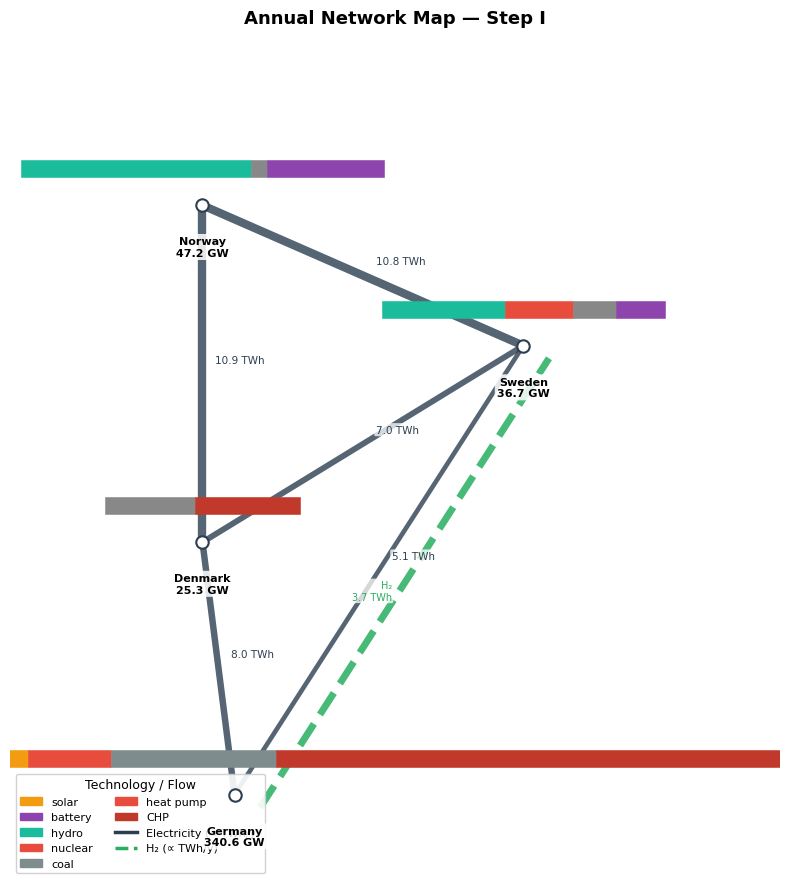

In [29]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import numpy as np

def plot_annual_network_map(net_i, countries_map):

    coords = {
        "Denmark": (10.0, 56.0),
        "Germany": (10.5, 51.5),
        "Sweden":  (15.0, 59.5),
        "Norway":  (10.0, 62.0),
    }

    COLORS = {
        "wind_combined": "#235ebc",
        "solar":         "#f39c12",
        "CCGT":          "#95a5a6",
        "battery":       "#8e44ad",
        "hydro":         "#1abc9c",
        "nuclear":       "#e74c3c",
        "coal":          "#7f8c8d",
        "heat pump":     "#e74c3c",
        "CHP":           "#c0392b",
    }

    fig, ax = plt.subplots(figsize=(8, 9))
    ax.set_facecolor("#eaf4fb")
    ax.set_xlim(7, 19)
    ax.set_ylim(50, 65)
    ax.axis("off")
    ax.set_title("Annual Network Map — Step I", fontsize=13, fontweight="bold", pad=10)

    # 1. ELECTRICITY LINES
    flows = {l: net_i.lines_t.p0[l].abs().sum() / 1e6 for l in net_i.lines.index}
    max_el = max(flows.values()) if flows else 1

    for line, twh in flows.items():
        b0, b1 = net_i.lines.loc[line, "bus0"], net_i.lines.loc[line, "bus1"]
        x0, y0 = coords[b0]
        x1, y1 = coords[b1]
        lw = 1.0 + 5.0 * (twh / max_el)
        ax.plot([x0, x1], [y0, y1], color="#2c3e50", linewidth=lw,
                solid_capstyle="round", alpha=0.8, zorder=2)
        ax.text((x0+x1)/2 + 0.2, (y0+y1)/2 + 0.2,
                f"{twh:.1f} TWh", fontsize=7.5, color="#2c3e50", zorder=5,
                bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.75, ec="none"))

    # 2. H2 PIPELINES
    h2_pairs = {}
    for lnk in [n for n in net_i.links.index if n.startswith("H2_")]:
        b0 = net_i.links.loc[lnk, "bus0"].replace(" H2", "")
        b1 = net_i.links.loc[lnk, "bus1"].replace(" H2", "")
        key = tuple(sorted([b0, b1]))
        h2_pairs[key] = h2_pairs.get(key, 0) + net_i.links_t.p0[lnk].abs().sum() / 1e6

    max_h2 = max(h2_pairs.values()) if h2_pairs else 1
    for (b0, b1), twh in h2_pairs.items():
        if twh < 0.01:
            continue
        x0, y0 = coords[b0]
        x1, y1 = coords[b1]
        ox, oy = (y1-y0)*0.05, -(x1-x0)*0.05
        lw = 1.0 + 4.0 * (twh / max_h2)
        ax.plot([x0+ox, x1+ox], [y0+oy, y1+oy],
                color="#27ae60", linewidth=lw, linestyle="--", alpha=0.85, zorder=3)
        ax.text((x0+x1)/2+ox - 0.2, (y0+y1)/2+oy - 0.3,
                f"H₂\n{twh:.1f} TWh", fontsize=7, color="#27ae60", zorder=5,
                ha="right",
                bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.75, ec="none"))

    # 3. CAPACITY BARS (horizontal stacked bar at each node)
    bar_scale = 0.12   # degrees per GW
    bar_height = 0.3

    for country in coords:
        cx, cy = coords[country]
        cap = {}

        for g in net_i.generators[net_i.generators.bus == country].index:
            carrier = net_i.generators.loc[g, "carrier"]
            cap[carrier] = cap.get(carrier, 0) + net_i.generators.loc[g, "p_nom_opt"] / 1e3

        for b in net_i.storage_units[net_i.storage_units.bus == country].index:
            cap["battery"] = cap.get("battery", 0) + net_i.storage_units.loc[b, "p_nom_opt"] / 1e3

        for code, cname in countries_map.items():
            if cname == country:
                if f"{code} heat pump" in net_i.links.index:
                    cap["heat pump"] = net_i.links.loc[f"{code} heat pump", "p_nom_opt"] / 1e3
                if f"{country} CHP" in net_i.links.index:
                    cap["CHP"] = net_i.links.loc[f"{country} CHP", "p_nom_opt"] / 1e3

        cap = {k: v for k, v in cap.items() if v > 0.01}
        total = sum(cap.values())

        # Draw stacked horizontal bar above the node
        x_start = cx - (total * bar_scale) / 2
        for carrier, gw in cap.items():
            width = gw * bar_scale
            rect = plt.Rectangle((x_start, cy + 0.5), width, bar_height,
                                  color=COLORS.get(carrier, "#888"),
                                  linewidth=0.4, edgecolor="white", zorder=4)
            ax.add_patch(rect)
            x_start += width

        # Node dot
        ax.scatter(cx, cy, s=80, color="white", edgecolors="#2c3e50",
                   linewidths=1.5, zorder=6)

        # Label
        ax.text(cx, cy - 0.55, f"{country}\n{total:.1f} GW",
                ha="center", va="top", fontsize=8, fontweight="bold", zorder=7,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.85, ec="none"))

    # 4. LEGEND
    patches = [mpatches.Patch(color=c, label=t) for t, c in COLORS.items()
               if any(t in net_i.generators.carrier.values or
                      t in ["battery", "heat pump", "CHP"] for _ in [0])]
    el_line = mlines.Line2D([], [], color="#2c3e50", lw=2.5, label="Electricity (∝ TWh/y)")
    h2_line = mlines.Line2D([], [], color="#27ae60", lw=2.5, ls="--", label="H₂ (∝ TWh/y)")

    ax.legend(handles=patches + [el_line, h2_line],
              loc="lower left", fontsize=8, title="Technology / Flow",
              title_fontsize=9, framealpha=0.9, ncol=2)

    plt.tight_layout()
    plt.savefig("network_map_step_I.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_annual_network_map(net_i, countries_map)